# Titanic Survival Analysis

# 1. Importing Libaries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette=["#950000", "#ECEF46", "#FF0090", "#9D0000"],
    context="notebook"
)

# 2. Importing Dataset and cleaning

In [2]:
dff = pd.read_csv('dataset/ship.csv')
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
dff

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# 3. Visualization

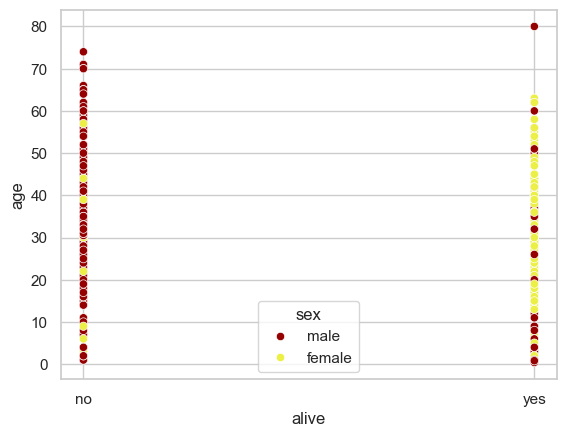

In [5]:
sns.scatterplot(data=df,y='age',x='alive',hue='sex')
plt.show()

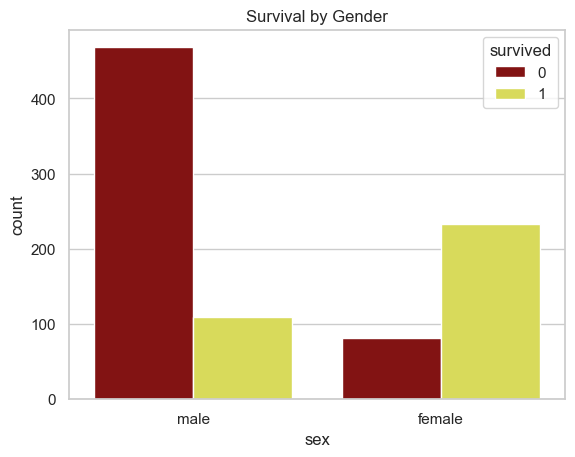

In [6]:
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival by Gender")
plt.show()

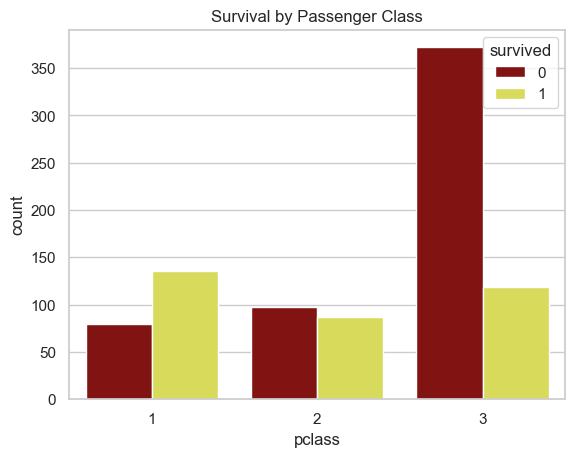

In [7]:
sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

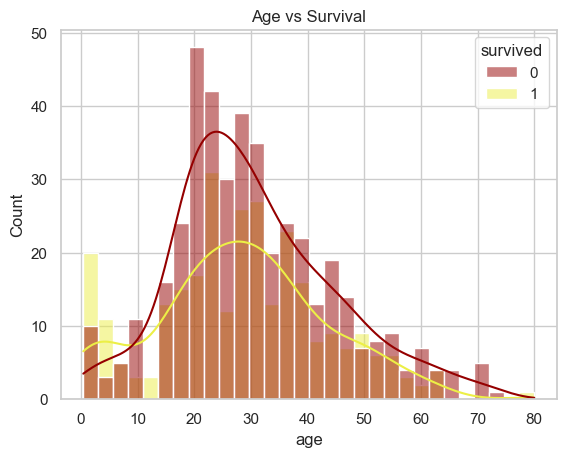

In [8]:
sns.histplot(data=df, x="age", hue="survived", kde=True, bins=30)
plt.title("Age vs Survival")
plt.show()

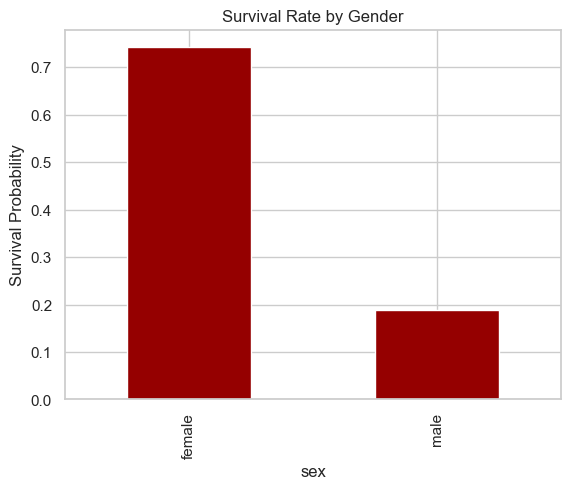

In [9]:
survival_rate = df.groupby("sex")["survived"].mean()
survival_rate.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.show()

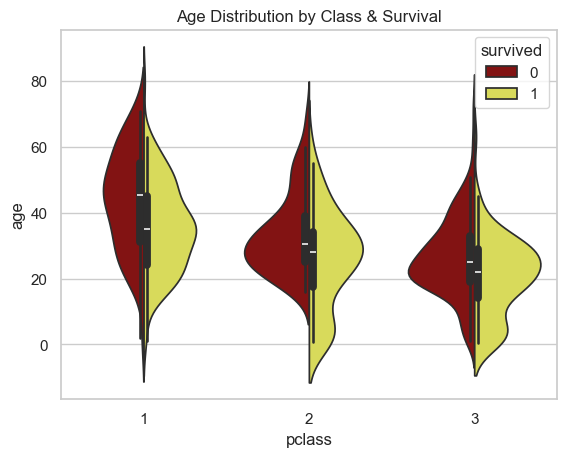

In [10]:
sns.violinplot(x="pclass", y="age", hue="survived", data=df, split=True)
plt.title("Age Distribution by Class & Survival")
plt.show()

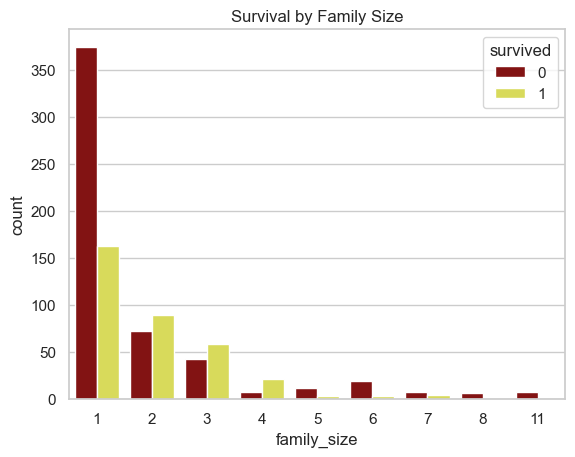

In [11]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

sns.countplot(x="family_size", hue="survived", data=df)
plt.title("Survival by Family Size")
plt.show()

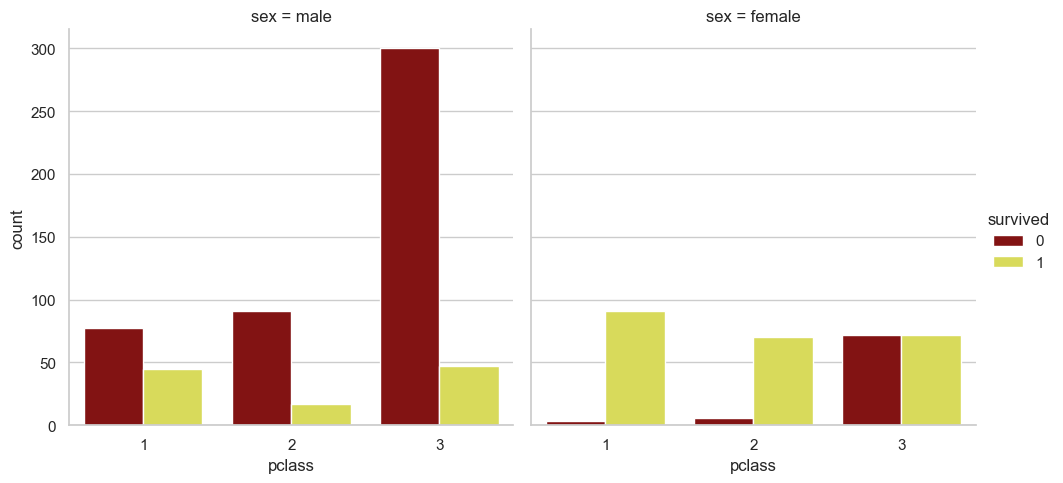

In [12]:
sns.catplot(x="pclass", hue="survived", col="sex", kind="count", data=df)
plt.show()

In [13]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


# 4. PreProcessing

In [14]:
#Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)

# Convert categorical → numeric
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['alone'] = df['alone'].astype(int) # as it was a bool value

#Drop useless columns
df.drop(['deck','survived', 'class', 'who', 'adult_male', 'embark_town','embarked'], axis=1, inplace=True)

# Features & target
X = df.drop('alive', axis=1)
Y = df['alive']

/var/folders/s3/7_ps073573349p4rwxh_fxzr0000gn/T/ipykernel_13418/4070193705.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


# 5. Model Traning and Evaulation

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=10
)

In [16]:
X_train

,pclass,sex,age,sibsp,parch,fare,alone,family_size
57,3,0,28.5,0,0,7.2292,1,1
717,2,1,27.0,0,0,10.5000,1,1
431,3,1,28.0,1,0,16.1000,0,2
633,1,0,28.0,0,0,0.0000,1,1
163,3,0,17.0,0,0,8.6625,1,1
...,...,...,...,...,...,...,...,...
369,1,1,24.0,0,0,69.3000,1,1
320,3,0,22.0,0,0,7.2500,1,1
527,1,0,28.0,0,0,221.7792,1,1
125,3,0,12.0,1,0,11.2417,0,2


### 5.1 Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)

#Eval Metrics
print("LR Accuracy:", accuracy_score(Y_test, Y_pred))

LR Accuracy: 0.8268156424581006


### 5.2 Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, Y_train)

Y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(Y_test, Y_pred_rf))

RF Accuracy: 0.8268156424581006


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, Y_train)

Y_pred_gb = gb.predict(X_test)
print("GB Accuracy:", accuracy_score(Y_test, Y_pred_gb))

GB Accuracy: 0.8491620111731844


# 6. Model Comparing

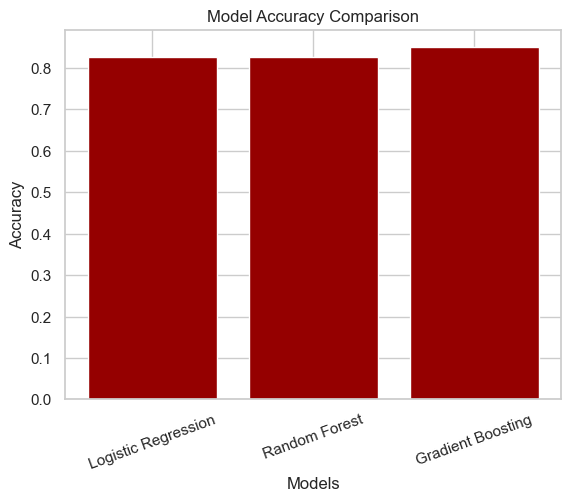

In [20]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

acc_lr = accuracy_score(Y_test, Y_pred)
acc_rf = accuracy_score(Y_test, Y_pred_rf)
acc_gb = accuracy_score(Y_test, Y_pred_gb)

models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
scores = [acc_lr, acc_rf, acc_gb]

plt.figure()
plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# 7. Save the trained model

In [21]:
import pickle

with open("model/lr _model.pkl", "wb") as file:  #
    pickle.dump(lr,file)


# 8. Saving the Package Version

In [22]:
import pkg_resources

# List of the packages you know you're using
required_packages = [
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'ipykernel',
]

requirements = []

for package in required_packages:
    try:
        version = pkg_resources.get_distribution(package).version
        requirements.append(f"{package}=={version}")
    except pkg_resources.DistributionNotFound:
        print(f"Package {package} not found in the environment.")

#requirements to a file
with open('requirements.txt', 'w') as f:
    for line in requirements:
        f.write(line + '\n')

/var/folders/s3/7_ps073573349p4rwxh_fxzr0000gn/T/ipykernel_13418/116971148.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
